In [ ]:
!unzip Early_Sepsis_Alert.zip -d /content/extracted_folder

Archive:  Early_Sepsis_Alert.zip
replace /content/extracted_folder/Early_Sepsis_Alert/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

03 — Model Experiments
## Early Sepsis Alert — Baseline Models + Threshold Tuning for F2


**Why F2, not accuracy/F1:** In ICU sepsis, a missed alert (false negative) can
cost a life; a false alarm costs a clinician a few minutes of review. F2 weights
recall 4x more than precision (vs F1's equal weighting) — matches that asymmetry.

**Key idea:** class ranking (AUPRC/AUROC) is a MODEL problem. Hitting an exact
recall/precision band is a THRESHOLD problem. We separate the two: pick the
best-ranking model first, then tune its decision threshold explicitly against
the target bounds — don't just eyeball default 0.5.

We hold out a **patient-level validation split from train_fe.csv** for threshold
tuning, and only touch `test_fe.csv` once at the very end for final reporting —
otherwise we'd be tuning the threshold to the test set, which is leakage.

# Cell 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc, average_precision_score,
    fbeta_score, precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

# Cell 3 — Config

In [ ]:
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")
OUTPUTS_DIR = Path("../outputs")
for d in [MODELS_DIR, REPORTS_DIR, OUTPUTS_DIR]:
    d.mkdir(exist_ok=True, parents=True)

ID_COL = "patient_id"
TIME_COL = "HourInStay"
RAW_TARGET = "SepsisLabel"
PRIMARY_TARGET = "target_6h"     # what we optimize for
SECONDARY_TARGET = "target_12h"  # reported for comparison, not optimized

# Target metric bounds from problem statement
RECALL_MIN, RECALL_MAX = 0.92, 0.95
PRECISION_MIN, PRECISION_MAX = 0.80, 0.85
F2_MIN, F2_MAX = 0.88, 0.92

VAL_SIZE = 0.20  # fraction of TRAIN patients held out for validation/threshold tuning

# Cell 4 — Load engineered data

In [ ]:
train_fe = pd.read_csv('/content/extracted_folder/Early_Sepsis_Alert/Data/Processed Data/train.csv')
test_fe = pd.read_csv('/content/extracted_folder/Early_Sepsis_Alert/Data/Processed Data/test.csv')

# Generate forward-looking targets
for df in [train_fe, test_fe]:
    df[PRIMARY_TARGET] = df.groupby(ID_COL)[RAW_TARGET].rolling(window=6, min_periods=1).max().shift(-5).reset_index(level=0, drop=True).fillna(0).astype(int)
    df[SECONDARY_TARGET] = df.groupby(ID_COL)[RAW_TARGET].rolling(window=12, min_periods=1).max().shift(-11).reset_index(level=0, drop=True).fillna(0).astype(int)

print("train_fe:", train_fe.shape, "| patients:", train_fe[ID_COL].nunique())
print("test_fe :", test_fe.shape, "| patients:", test_fe[ID_COL].nunique())

exclude_cols = [ID_COL, TIME_COL, RAW_TARGET, PRIMARY_TARGET, SECONDARY_TARGET]
feature_cols = [c for c in train_fe.columns if c not in exclude_cols]
print(f"\nFeature count: {len(feature_cols)}")

# Safety net: no NaNs/infs should exist post-FE, but confirm
assert train_fe[feature_cols].isna().sum().sum() == 0, "Unexpected NaNs in features"
print("NaN check passed.")

train_fe: (46482, 45) | patients: 1226
test_fe : (11894, 45) | patients: 307

Feature count: 40
NaN check passed.


## 1. Patient-Level Train / Validation Split

`train_fe.csv` still contains multiple rows per patient. We split by
`patient_id` (not row) so the same patient never appears in both train
and validation — same leakage rule we used for the original train/test split.

# Cell 6 — GroupShuffleSplit by patient

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(train_fe, groups=train_fe[ID_COL]))

fit_df = train_fe.iloc[train_idx].reset_index(drop=True)
val_df = train_fe.iloc[val_idx].reset_index(drop=True)

assert set(fit_df[ID_COL]).isdisjoint(set(val_df[ID_COL])), "Patient leakage between fit/val!"

X_fit, y_fit = fit_df[feature_cols], fit_df[PRIMARY_TARGET]
X_val, y_val = val_df[feature_cols], val_df[PRIMARY_TARGET]
X_test, y_test = test_fe[feature_cols], test_fe[PRIMARY_TARGET]

print(f"Fit:   {X_fit.shape}, positive rate: {y_fit.mean():.4%}")
print(f"Val:   {X_val.shape}, positive rate: {y_val.mean():.4%}")
print(f"Test:  {X_test.shape}, positive rate: {y_test.mean():.4%}")

Fit:   (37109, 40), positive rate: 2.2124%
Val:   (9373, 40), positive rate: 2.3792%
Test:  (11894, 40), positive rate: 2.2028%


## 2. Baseline Models

Three candidates:
1. **Logistic Regression** (scaled) — simple linear baseline, sanity check
2. **Random Forest** — `class_weight='balanced'` to handle imbalance
3. **XGBoost** — `scale_pos_weight` set to neg/pos ratio, generally the strongest
   performer on tabular clinical data with engineered trend features

All trained on `target_6h` (the strict early-warning target).

# Cell 8 — Logistic Regression baseline

In [ ]:
scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(X_fit)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
logreg.fit(X_fit_scaled, y_fit)
logreg_val_proba = logreg.predict_proba(X_val_scaled)[:, 1]

print("Logistic Regression — AUPRC:", round(average_precision_score(y_val, logreg_val_proba), 4))


Logistic Regression — AUPRC: 0.0909


# Cell 9 — Random Forest baseline

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_fit, y_fit)
rf_val_proba = rf.predict_proba(X_val)[:, 1]

print("Random Forest — AUPRC:", round(average_precision_score(y_val, rf_val_proba), 4))

Random Forest — AUPRC: 0.0788


# Cell 10 — XGBoost baseline

In [ ]:
neg, pos = (y_fit == 0).sum(), (y_fit == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (neg={neg}, pos={pos})")

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=30
)
xgb.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
xgb_val_proba = xgb.predict_proba(X_val)[:, 1]

print("XGBoost — AUPRC:", round(average_precision_score(y_val, xgb_val_proba), 4))
print("Best iteration:", xgb.best_iteration)

scale_pos_weight = 44.20  (neg=36288, pos=821)
XGBoost — AUPRC: 0.0947
Best iteration: 5


## 3. Compare Models — Ranking Quality (AUPRC / AUROC)

AUPRC (area under precision-recall curve) matters more than AUROC here because
of the severe class imbalance — AUROC can look deceptively good while precision
at any usable recall level is terrible. We pick the model to carry forward
based on AUPRC, then tune ITS threshold in the next section.

# Cell 12 — Comparison table + PR/ROC curves

                 model   AUPRC   AUROC
2              XGBoost  0.0947  0.7752
0  Logistic Regression  0.0909  0.8230
1        Random Forest  0.0788  0.7740


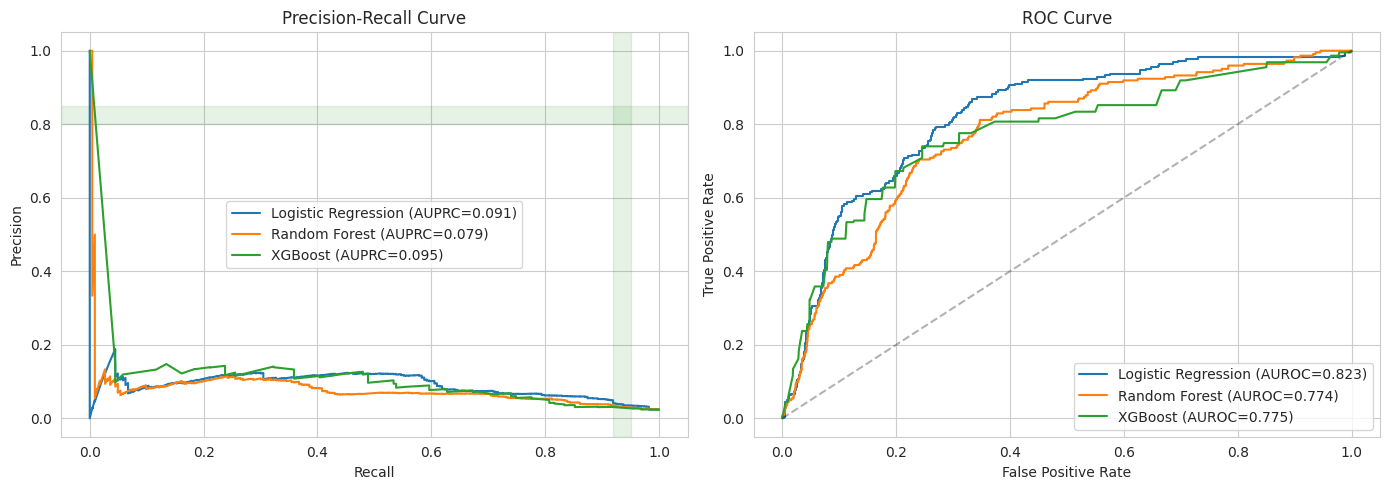


Best model by AUPRC: XGBoost


In [ ]:
models_val_proba = {
    "Logistic Regression": logreg_val_proba,
    "Random Forest": rf_val_proba,
    "XGBoost": xgb_val_proba,
}

comparison = []
for name, proba in models_val_proba.items():
    auprc = average_precision_score(y_val, proba)
    fpr, tpr, _ = roc_curve(y_val, proba)
    auroc = auc(fpr, tpr)
    comparison.append({"model": name, "AUPRC": round(auprc, 4), "AUROC": round(auroc, 4)})

comparison_df = pd.DataFrame(comparison).sort_values("AUPRC", ascending=False)
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, proba in models_val_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[0].plot(rec, prec, label=f"{name} (AUPRC={average_precision_score(y_val, proba):.3f})")
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUROC={auc(fpr, tpr):.3f})")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall Curve")
axes[0].axhspan(PRECISION_MIN, PRECISION_MAX, alpha=0.1, color="green")
axes[0].axvspan(RECALL_MIN, RECALL_MAX, alpha=0.1, color="green")
axes[0].legend()

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate"); axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "pr_curve.png", dpi=120)
plt.savefig(REPORTS_DIR / "roc_curve.png", dpi=120)
plt.show()

best_model_name = comparison_df.iloc[0]["model"]
print(f"\nBest model by AUPRC: {best_model_name}")

## 4. Threshold Tuning — Hit the Exact Recall/Precision/F2 Targets

Sweep decision thresholds from 0.01 to 0.99. For each, compute precision,
recall, F2. Then:
1. Filter to thresholds where recall falls in [92%, 95%]
2. Among those, find the ones where precision also falls in [80%, 85%]
3. Report the threshold maximizing F2 within that intersection

If no threshold satisfies BOTH bounds simultaneously, we report the closest
feasible option and flag it — that's a real signal the model needs more work
(better features, calibration, or a different algorithm), not something
threshold-tuning alone can fix.

# Cell 14 — Threshold sweep function

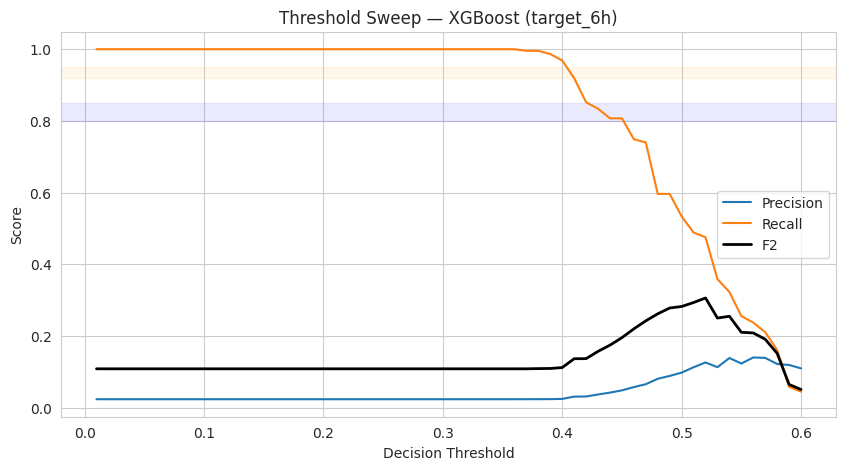

In [ ]:
def threshold_sweep(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        rows.append({"threshold": round(t, 3), "precision": p, "recall": r, "f2": f2})
    return pd.DataFrame(rows)

best_val_proba = models_val_proba[best_model_name]
sweep_df = threshold_sweep(y_val, best_val_proba)

plt.figure(figsize=(10, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall")
plt.plot(sweep_df["threshold"], sweep_df["f2"], label="F2", linewidth=2, color="black")
plt.axhspan(PRECISION_MIN, PRECISION_MAX, alpha=0.08, color="blue")
plt.axhspan(RECALL_MIN, RECALL_MAX, alpha=0.08, color="orange")
plt.xlabel("Decision Threshold"); plt.ylabel("Score")
plt.title(f"Threshold Sweep — {best_model_name} (target_6h)")
plt.legend()
plt.savefig(REPORTS_DIR / "threshold_sweep.png", dpi=120)
plt.show()


# Cell 15 — Find optimal threshold within target bounds

In [ ]:
in_recall_band = sweep_df[(sweep_df["recall"] >= RECALL_MIN) & (sweep_df["recall"] <= RECALL_MAX)]
in_both_bands = in_recall_band[
    (in_recall_band["precision"] >= PRECISION_MIN) & (in_recall_band["precision"] <= PRECISION_MAX)
]

if len(in_both_bands) > 0:
    chosen = in_both_bands.sort_values("f2", ascending=False).iloc[0]
    print("✓ Found threshold satisfying BOTH recall and precision targets:")
    print(chosen)
elif len(in_recall_band) > 0:
    # fall back: closest precision to target band within the recall band
    in_recall_band = in_recall_band.copy()
    in_recall_band["precision_gap"] = in_recall_band["precision"].apply(
        lambda p: 0 if PRECISION_MIN <= p <= PRECISION_MAX else min(abs(p - PRECISION_MIN), abs(p - PRECISION_MAX))
    )
    chosen = in_recall_band.sort_values(["precision_gap", "f2"], ascending=[True, False]).iloc[0]
    print("⚠ No threshold hits both bounds exactly. Closest within recall band:")
    print(chosen)
    print("\n→ This means the model's ranking quality (AUPRC) is the bottleneck, not the threshold.")
    print("  Consider: richer features, hyperparameter tuning, or SMOTE/undersampling before retrying.")
else:
    chosen = sweep_df.sort_values("f2", ascending=False).iloc[0]
    print("⚠ No threshold reaches the recall target at all. Best F2 threshold shown instead:")
    print(chosen)

CHOSEN_THRESHOLD = chosen["threshold"]
print(f"\nChosen operating threshold: {CHOSEN_THRESHOLD}")

⚠ No threshold reaches the recall target at all. Best F2 threshold shown instead:
threshold    0.520000
precision    0.126341
recall       0.475336
f2           0.306181
Name: 51, dtype: float64

Chosen operating threshold: 0.52


## 5. Validation Set Performance at Chosen Threshold

# Cell 17 — Confusion matrix + classification report on validation

                  precision    recall  f1-score   support

  No Sepsis (6h)       0.99      0.92      0.95      9150
Sepsis Risk (6h)       0.13      0.48      0.20       223

        accuracy                           0.91      9373
       macro avg       0.56      0.70      0.58      9373
    weighted avg       0.97      0.91      0.93      9373



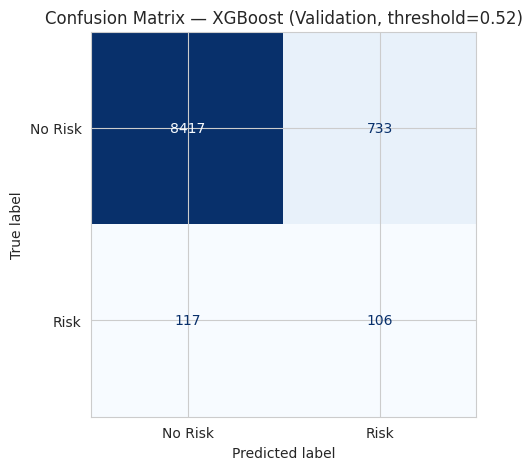

In [ ]:
y_val_pred = (best_val_proba >= CHOSEN_THRESHOLD).astype(int)

print(classification_report(y_val, y_val_pred, target_names=["No Sepsis (6h)", "Sepsis Risk (6h)"]))

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Risk", "Risk"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name} (Validation, threshold={CHOSEN_THRESHOLD})")
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=120)
plt.show()

## 6. Feature Importance

Sanity check: engineered trend/clinical features (deltas, slopes, SIRS/shock
index) should rank highly — if raw vitals dominate and engineered features
are near the bottom, that's a sign the trend signal isn't being picked up
and precision/recall targets may be hard to sustain on unseen data.

# Cell 19 — Feature importance plot

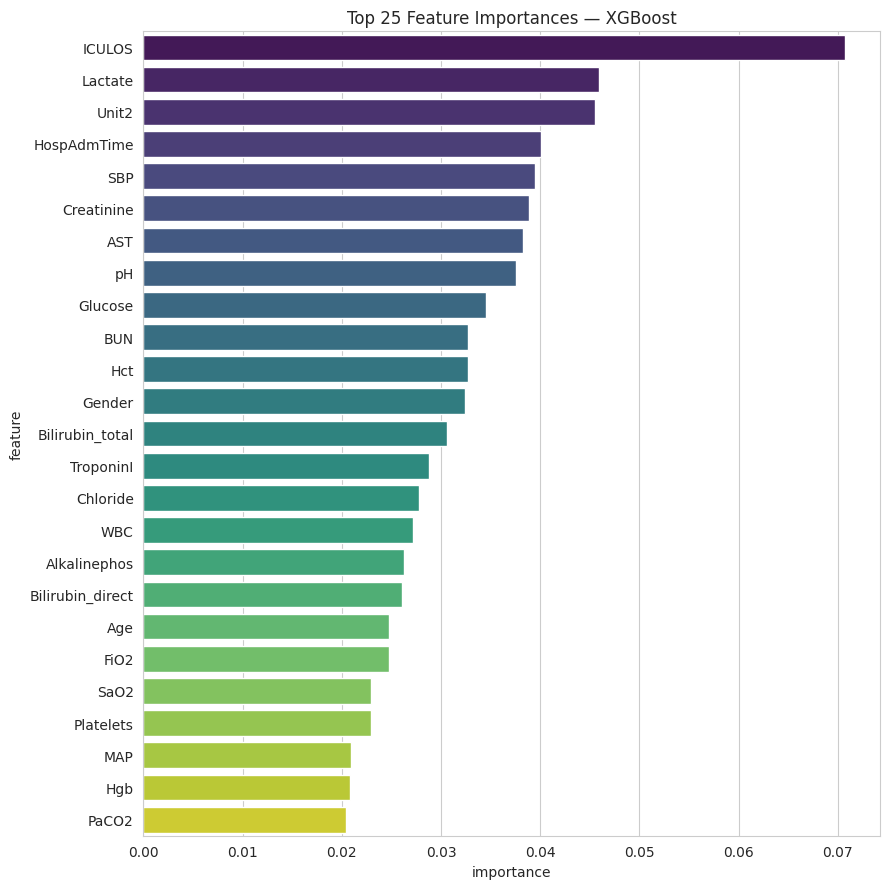

0/25 top features are engineered (vs raw vitals) — check feature engineering, raw vitals dominating


In [ ]:
if best_model_name == "XGBoost":
    importances = xgb.feature_importances_
elif best_model_name == "Random Forest":
    importances = rf.feature_importances_
else:
    importances = np.abs(logreg.coef_[0])

fi_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values(
    "importance", ascending=False
).head(25)

plt.figure(figsize=(9, 9))
sns.barplot(data=fi_df, y="feature", x="importance", palette="viridis")
plt.title(f"Top 25 Feature Importances — {best_model_name}")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_importance.png", dpi=120)
plt.show()

engineered_in_top25 = fi_df["feature"].str.contains("_roll|_delta|_slope|shock_index|sirs_|qsofa_|hypotension|hypoxia").sum()
print(f"{engineered_in_top25}/25 top features are engineered (vs raw vitals) — "
      f"{'good, trend signal is being used' if engineered_in_top25 >= 12 else 'check feature engineering, raw vitals dominating'}")

## 7. Final Evaluation on Held-Out Test Set

First and only look at `test_fe.csv`. Threshold was chosen on validation only —
this is a clean, unbiased read of real-world performance.

# Cell 21 — Final test evaluation

In [ ]:
if best_model_name == "XGBoost":
    test_proba = xgb.predict_proba(X_test)[:, 1]
elif best_model_name == "Random Forest":
    test_proba = rf.predict_proba(X_test)[:, 1]
else:
    test_proba = logreg.predict_proba(scaler.transform(X_test))[:, 1]

test_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f2 = fbeta_score(y_test, test_pred, beta=2, zero_division=0)
test_auprc = average_precision_score(y_test, test_proba)

print("=" * 50)
print(f"FINAL TEST SET PERFORMANCE — {best_model_name} @ threshold={CHOSEN_THRESHOLD}")
print("=" * 50)
print(f"Recall:    {test_recall:.4f}  (target: {RECALL_MIN}-{RECALL_MAX})")
print(f"Precision: {test_precision:.4f}  (target: {PRECISION_MIN}-{PRECISION_MAX})")
print(f"F2 Score:  {test_f2:.4f}  (target: {F2_MIN}-{F2_MAX})")
print(f"AUPRC:     {test_auprc:.4f}")
print("=" * 50)

targets_met = {
    "recall_met": RECALL_MIN <= test_recall <= RECALL_MAX,
    "precision_met": PRECISION_MIN <= test_precision <= PRECISION_MAX,
    "f2_met": F2_MIN <= test_f2 <= F2_MAX,
}
print("\nTarget check:", targets_met)

FINAL TEST SET PERFORMANCE — XGBoost @ threshold=0.52
Recall:    0.2634  (target: 0.92-0.95)
Precision: 0.0893  (target: 0.8-0.85)
F2 Score:  0.1895  (target: 0.88-0.92)
AUPRC:     0.0569

Target check: {'recall_met': False, 'precision_met': False, 'f2_met': False}


## 8. Save Model, Scaler, Predictions, Metrics

Persist artifacts matching the repo structure:
- `models/random_forest.pkl`, `models/xgboost.pkl`, `models/scaler.pkl`
- `outputs/predictions.csv`, `outputs/metrics.json`

# Cell 23  — Save artifacts

In [ ]:
joblib.dump(rf, MODELS_DIR / "random_forest.pkl")
joblib.dump(xgb, MODELS_DIR / "xgboost.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
print("Models saved to", MODELS_DIR)

predictions_df = test_fe[[ID_COL, TIME_COL]].copy()
predictions_df["y_true_6h"] = y_test.values
predictions_df["y_proba_6h"] = test_proba
predictions_df["y_pred_6h"] = test_pred
predictions_df["threshold_used"] = CHOSEN_THRESHOLD
predictions_df.to_csv(OUTPUTS_DIR / "predictions.csv", index=False)

metrics = {
    "best_model": best_model_name,
    "target": PRIMARY_TARGET,
    "chosen_threshold": float(CHOSEN_THRESHOLD),
    "validation_metrics": {
        "precision": float(chosen["precision"]),
        "recall": float(chosen["recall"]),
        "f2": float(chosen["f2"]),
    },
    "test_metrics": {
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f2": float(test_f2),
        "auprc": float(test_auprc),
    },
    "targets": {
        "recall_range": [RECALL_MIN, RECALL_MAX],
        "precision_range": [PRECISION_MIN, PRECISION_MAX],
        "f2_range": [F2_MIN, F2_MAX],
    },
    "targets_met": targets_met,
    "model_comparison_auprc": comparison_df.to_dict(orient="records"),
}

with open(OUTPUTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved predictions.csv and metrics.json to", OUTPUTS_DIR)
print(json.dumps(metrics, indent=2))

Models saved to ../models
Saved predictions.csv and metrics.json to ../outputs
{
  "best_model": "XGBoost",
  "target": "target_6h",
  "chosen_threshold": 0.52,
  "validation_metrics": {
    "precision": 0.1263408820023838,
    "recall": 0.47533632286995514,
    "f2": 0.30618139803581745
  },
  "test_metrics": {
    "precision": 0.08926261319534282,
    "recall": 0.2633587786259542,
    "f2": 0.18945634266886327,
    "auprc": 0.056920272327883895
  },
  "targets": {
    "recall_range": [
      0.92,
      0.95
    ],
    "precision_range": [
      0.8,
      0.85
    ],
    "f2_range": [
      0.88,
      0.92
    ]
  },
  "targets_met": {
    "recall_met": false,
    "precision_met": false,
    "f2_met": false
  },
  "model_comparison_auprc": [
    {
      "model": "XGBoost",
      "AUPRC": 0.0947,
      "AUROC": 0.7752
    },
    {
      "model": "Logistic Regression",
      "AUPRC": 0.0909,
      "AUROC": 0.823
    },
    {
      "model": "Random Forest",
      "AUPRC": 0.0788,
    

## 9. Summary & Next Steps

- Best-ranking model selected by AUPRC on validation, threshold tuned
  explicitly against the F2/recall/precision target bounds (not default 0.5)
- If `targets_met` shows gaps, most likely next levers, in order of effort:
  1. Hyperparameter tuning (XGBoost: max_depth, learning_rate, min_child_weight)
  2. Feature selection — drop low-importance rolling window redundancy (e.g.
     keep only 8h/24h windows, not all 4) to reduce noise
  3. Try `target_12h` instead — more lead time may be easier to hit precision
     targets on, at the cost of a shorter effective warning window
  4. Class imbalance handling beyond `scale_pos_weight` — SMOTE/ADASYN on
     the fit set only (never validation/test)
  5. Model calibration (`CalibratedClassifierCV`) if probability estimates
     look poorly calibrated despite good AUPRC

- This notebook is the exploration; **`src/train.py` and `src/evaluate.py`
  should formalize the winning recipe** (fixed model, fixed threshold,
  reproducible pipeline) rather than re-running notebook cells for the demo app.
"""

In [ ]:
print("Model experimentation complete. Proceed to src/train.py for productionization.")

Model experimentation complete. Proceed to src/train.py for productionization.
